---
language: hi
title: Hindi BPE Tokenizer
description: A Hindi BPE tokenizer for efficient text compression and processing.
emoji: 🌐
color: blue
pinned: true
tags:
- hindi
- tokenizer
- bpe
- subword
- text-processing
pipeline_tag: text2text-generation
inference: true
license: mit
app_file: app.py
sdk: gradio
spaces:
- aayushraina/bpe-hindi
---

# Hindi Byte Pair Encoding (BPE) Tokenizer

A specialized BPE tokenizer for Hindi text that achieves efficient compression while maintaining linguistic coherence.

## Online Demo

Try the tokenizer in your browser: [Hindi BPE Tokenizer Demo](https://huggingface.co/spaces/aayushraina/bpe-hindi)

## Project Overview

This project implements a Byte Pair Encoding (BPE) tokenizer specifically designed for Hindi text. It features:
- Efficient trie-based tokenization
- Visualization of training progress
- Compression ratio optimization
- Support for large Hindi text datasets
- Hugging Face compatibility

## Project Structure
hindi-bpe/
├── data/ # Dataset directory
│ ├── train/ # Training data
│ └── valid/ # Validation data
├── tokenizer/ # Saved tokenizer files
│ ├── encoder.json # Encoder state
│ └── vocab_stats.json # Vocabulary statistics
├── output/ # Visualization outputs
├── byte_pair_encoder.py # Core BPE implementation
├── hindi_bpe.py # Hindi-specific wrapper
├── test_hindi_bpe.py # Test suite
└── requirements.txt # Dependencies

## Training stats
    - Iteration 4500:
    - Vocabulary size: 4,477
    - Data size: 448,754
    - Compression ratio: 3.66
    - Max token length: 64

## File Descriptions

1. **byte_pair_encoder.py**
   - Core BPE implementation
   - Trie-based tokenization
   - Training statistics tracking
   - Visualization utilities

2. **hindi_bpe.py**
   - Hindi-specific tokenizer wrapper
   - Text preprocessing
   - Model saving/loading
   - Compression ratio calculation

3. **app.py**
   - Interactive web interface
   - Real-time tokenization
   - Training visualization
   - Model parameter tuning

4. **test_hindi_bpe.py**
   - Test suite for tokenizer
   - Performance benchmarks
   - Example usage

## Installation
    - bash
    - Clone repository
    - git clone https://github.com/yourusername/hindi-bpe.git
    - cd hindi-bpe
    - pip install -r requirements.txt

## Download and prepare dataset
    - python download_dataset.py
  
### Web Interface
    - streamlit run app.py

### Test-
    - python test_hindi_bpe.py
    - The test suite includes:
    - Training pipeline verification
    - Compression ratio validation
    - Token count requirements
    - Encoding/decoding accuracy

## Performance Metrics

    The tokenizer aims to achieve:
    - Vocabulary size < 5000 tokens
    - Compression ratio ≥ 3.2
    - Fast encoding/decoding
    - Memory-efficient operation

## Contributing

1. Fork the repository
2. Create feature branch
3. Commit changes
4. Push to branch
5. Create Pull Request

## License

This project is licensed under the MIT License - see the LICENSE file for details.


In [ ]:
from typing import List, Dict, Optional
from tqdm import tqdm
from collections import Counter
from matplotlib import pyplot as plt
import json
from pathlib import Path

class TrieNode:
    """Node in the prefix tree (trie) for fast token matching"""
    def __init__(self):
        self.children = {}
        self.is_token = False
        self.token = None

class BytePairEncoder:
    def __init__(self, text: str):
        # Initialize vocabulary from characters
        self.chars = sorted(list(set(text)))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for i, ch in enumerate(self.chars)}

        # Initial encoding of text
        self.data = [self.stoi[c] for c in text]

        # Statistics tracking
        self.stats = {
            "vocab_sizes": [len(self.chars)],
            "data_sizes": [len(self.data)],
            "compression_ratios": [1.0],
            "merge_counts": [],
            "tokens_created": [],
            "max_token_lengths": [1],
        }

        # Store original length for compression ratio
        self.original_length = len(self.data)
        self.max_token_length = 1

    def get_digram_stats(self) -> Counter:
        """Get digram counts"""
        counts = Counter()
        for pair in zip(self.data, self.data[1:]):
            pair = (int(pair[0]), int(pair[1]))
            counts[pair] += 1
        return counts

    def encode_to_vocab_size(self, target_vocab_size: int, plot_interval: Optional[int] = None,
                           print_interval: int = 100) -> None:
        """Train until reaching target vocabulary size"""
        pbar = tqdm(total=target_vocab_size, desc="Training BPE", initial=len(self.chars))

        iteration = 0
        while len(self.itos) < target_vocab_size:
            result = self._merge_step()
            if result is None:
                break

            iteration += 1
            pbar.update(1)

            if print_interval and iteration % print_interval == 0:
                self._print_progress(iteration)

            if plot_interval and iteration % plot_interval == 0:
                self.plot_statistics(iteration=iteration)

        pbar.close()

    def _merge_step(self):
        """Perform one merge operation"""
        stats = self.get_digram_stats()
        if not stats:
            return None

        top_pair, count = max(stats.items(), key=lambda x: x[1])
        new_token = self._add_token(top_pair)
        self.data = self._replace_pairs(top_pair, new_token)
        self._update_stats(count)

        return new_token, count

    def _add_token(self, pair: tuple) -> int:
        """Add new token to vocabulary"""
        token_str = self.itos[pair[0]] + self.itos[pair[1]]
        token_id = len(self.itos)
        self.stoi[token_str] = token_id
        self.itos[token_id] = token_str
        self.max_token_length = max(self.max_token_length, len(token_str))
        return token_id

    def _replace_pairs(self, pair: tuple, new_token: int) -> List[int]:
        """Replace all occurrences of pair with new token"""
        result = []
        i = 0
        while i < len(self.data):
            if i < len(self.data) - 1 and self.data[i] == pair[0] and self.data[i + 1] == pair[1]:
                result.append(new_token)
                i += 2
            else:
                result.append(self.data[i])
                i += 1
        return result

    def _update_stats(self, merge_count: int):
        """Update training statistics"""
        self.stats["vocab_sizes"].append(len(self.itos))
        self.stats["data_sizes"].append(len(self.data))
        compression = self.original_length / len(self.data)
        self.stats["compression_ratios"].append(compression)
        self.stats["merge_counts"].append(merge_count)
        self.stats["tokens_created"].append(self.itos[len(self.itos)-1])
        self.stats["max_token_lengths"].append(self.max_token_length)

    def plot_statistics(self, iteration: Optional[int] = None):
        """Plot training statistics"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # Plot training metrics
        ax1.plot(self.stats["vocab_sizes"], self.stats["data_sizes"])
        ax1.set_title("Vocabulary vs Dataset Size")

        ax2.plot(self.stats["vocab_sizes"], self.stats["compression_ratios"])
        ax2.set_title("Compression Ratio Progress")

        if self.stats["merge_counts"]:
            ax3.hist(self.stats["merge_counts"], bins=30)
            ax3.set_title("Merge Counts Distribution")

        if self.stats["tokens_created"]:
            lengths = [len(t) for t in self.stats["tokens_created"]]
            ax4.plot(range(len(lengths)), lengths)
            ax4.set_title("Token Length Evolution")

        plt.tight_layout()
        plt.show()

    def save_to_file(self, filepath: Path):
        """Save encoder state"""
        state = {
            "chars": self.chars,
            "stoi": self.stoi,
            "max_token_length": self.max_token_length,
            "stats": self.stats
        }
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(state, f, ensure_ascii=False, indent=2)

    @classmethod
    def load_from_file(cls, filepath: Path):
        """Load encoder state"""
        with open(filepath, 'r', encoding='utf-8') as f:
            state = json.load(f)

        instance = cls("")  # Create empty instance
        instance.chars = state["chars"]
        instance.stoi = state["stoi"]
        instance.itos = {int(i): s for s, i in state["stoi"].items()}
        instance.max_token_length = state["max_token_length"]
        instance.stats = state["stats"]

        return instance

    def _print_progress(self, iteration: int):
        """Print training progress"""
        print(f"\nIteration {iteration}:")
        print(f"Vocabulary size: {len(self.itos):,}")
        print(f"Data size: {len(self.data):,}")
        print(f"Compression ratio: {self.stats['compression_ratios'][-1]:.2f}")

        if self.stats["merge_counts"]:
            last_merge = self.stats["merge_counts"][-1]
            last_token = self.stats["tokens_created"][-1]
            print(f"Last merge count: {last_merge:,}")
            print(f"Last token created: '{last_token}'")

        print(f"Max token length: {self.max_token_length}")

class TokenizerInternal:
    """Tokenizer using trained BPE model"""
    def __init__(self, encoder: BytePairEncoder):
        self.stoi = encoder.stoi
        self.max_token_length = encoder.max_token_length
        self._trie = self._build_trie()

    def _build_trie(self) -> TrieNode:
        """Build trie for efficient tokenization"""
        root = TrieNode()
        for token in self.stoi:
            node = root
            for char in token:
                if char not in node.children:
                    node.children[char] = TrieNode()
                node = node.children[char]
            node.is_token = True
            node.token = token
        return root

    def tokenize(self, text: str) -> List[str]:
        """Tokenize text using trie-based matching"""
        tokens = []
        pos = 0
        while pos < len(text):
            token = self._find_longest_token(text[pos:])
            tokens.append(token)
            pos += len(token)
        return tokens

    def _find_longest_token(self, text: str) -> str:
        """Find longest matching token starting at current position"""
        node = self._trie
        longest = text[0]
        current = ""

        for char in text[:self.max_token_length]:
            if char not in node.children:
                break
            current += char
            node = node.children[char]
            if node.is_token:
                longest = node.token

        return longest

In [ ]:
import re
from collections import Counter
from typing import Dict, List, Tuple, Set
import unicodedata
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import json
from matplotlib import pyplot as plt
from pathlib import Path

class HindiBPE:
    def __init__(self, vocab_size: int = 5000):
        print(f"\nInitializing HindiBPE with max vocab size: {vocab_size}")
        self.vocab_size = vocab_size
        self.encoder = None

    def train(self, text: str) -> None:
        """Train BPE on Hindi text."""
        print("\nInitializing BytePairEncoder...")
        self.encoder = BytePairEncoder(text)

        print("\nTraining BPE...")
        self.encoder.encode_to_vocab_size(
            target_vocab_size=self.vocab_size,
            plot_interval=1000,
            print_interval=100
        )

        # Plot final statistics
        self.encoder.plot_statistics()

        # Save the trained model
        self.save_tokenizer()

    def encode(self, text: str) -> List[str]:
        """Encode Hindi text using trained tokenizer."""
        if self.encoder is None:
            raise ValueError("Tokenizer not trained yet!")

        print("\nTokenizing text...")
        tokenizer = TokenizerInternal(self.encoder)
        tokens = list(tokenizer.tokenize(text))

        compression = self.calculate_compression_ratio(text, tokens)
        print(f"\nEncoding completed:")
        print(f"Token count: {len(tokens)}")
        print(f"Unique tokens: {len(set(tokens))}")
        print(f"Compression ratio: {compression:.2f}")

        return tokens

    def decode(self, tokens: List[str]) -> str:
        """Decode tokens back to text."""
        if self.encoder is None:
            raise ValueError("Tokenizer not trained yet!")

        print("\nDecoding tokens...")
        decoded = "".join(tokens)
        print(f"Decoded length: {len(decoded)} characters")
        return decoded

    def save_tokenizer(self, path: str = "tokenizer") -> None:
        """Save the tokenizer to disk."""
        save_dir = Path(path)
        save_dir.mkdir(exist_ok=True)

        # Save the encoder
        self.encoder.save_to_file(save_dir / "encoder.json")

        # Save vocabulary stats
        stats = self.get_token_statistics()
        with open(save_dir / "vocab_stats.json", "w") as f:
            json.dump(stats, f, indent=2)

        print(f"Tokenizer saved to {save_dir}")

    @classmethod
    def load_tokenizer(cls, path: str = "tokenizer") -> "HindiBPE":
        """Load a trained tokenizer from disk."""
        load_dir = Path(path)
        if not load_dir.exists():
            raise FileNotFoundError(f"Tokenizer directory not found: {load_dir}")

        # Create instance
        instance = cls()

        # Load encoder
        instance.encoder = BytePairEncoder.load_from_file(load_dir / "encoder.json")

        print(f"Loaded tokenizer from {load_dir}")
        print(f"Vocabulary size: {len(instance.encoder.itos)}")
        return instance

    def get_token_statistics(self) -> Dict:
        """Get statistics about the learned tokens."""
        if self.encoder is None:
            raise ValueError("Tokenizer not trained yet!")

        token_lengths = [len(token) for token in self.encoder.itos.values()]
        return {
            'vocab_size': len(self.encoder.itos),
            'avg_token_length': sum(token_lengths) / len(token_lengths),
            'min_token_length': min(token_lengths),
            'max_token_length': max(token_lengths),
            'length_distribution': Counter(token_lengths),
            'training_stats': self.encoder.stats
        }

    def calculate_compression_ratio(self, text: str, tokens: List[str]) -> float:
        """Calculate compression ratio."""
        original_size = len(text)
        encoded_size = sum(len(token) for token in tokens)
        return original_size / encoded_size

def preprocess_hindi_text(text: str) -> str:
    """Preprocess Hindi text for better BPE training."""
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text.strip())

    # Normalize Unicode characters
    text = unicodedata.normalize('NFKC', text)

    # Remove unnecessary punctuation (keep essential ones)
    text = re.sub(r'[^\u0900-\u097F\s।]', '', text)

    return text

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.4/321.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import kagglehub
from pathlib import Path
import shutil
import pandas as pd
import re
import nltk
from typing import List, Dict
from tqdm import tqdm

def count_hindi_words(text: str) -> int:
    """Count words in Hindi text."""
    words = text.strip().split()
    hindi_words = [w for w in words if re.search(r'[\u0900-\u097F]', w)]
    return len(hindi_words)

def create_dataframe_from_files(downloaded_paths: List[str]) -> pd.DataFrame:
    """Create a DataFrame from downloaded text files."""
    print("\nCreating DataFrame from text files...")

    data = []
    for file_path in tqdm(downloaded_paths):
        if file_path.endswith('.txt'):
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read().strip()

                # Split into title and text (assuming first line is title)
                lines = content.split('\n', 1)
                title = lines[0].strip()
                text = lines[1].strip() if len(lines) > 1 else ""

                data.append({
                    'title': title,
                    'text': text,
                    'word_count': count_hindi_words(content)
                })
            except Exception as e:
                print(f"Error reading file {file_path}: {e}")
                continue

    df = pd.DataFrame(data)
    print(f"Created DataFrame with {len(df)} articles")
    return df

def process_and_split_articles(df: pd.DataFrame,
                             output_dir: Path,
                             train_ratio: float = 0.8,
                             min_words: int = 100,
                             max_words: int = 5000) -> Dict[str, int]:
    """Process articles and split them into files based on word count."""

    # Create output directories
    train_dir = output_dir / "train"
    valid_dir = output_dir / "valid"
    train_dir.mkdir(exist_ok=True)
    valid_dir.mkdir(exist_ok=True)

    stats = {'train': 0, 'valid': 0, 'skipped': 0}

    print("\nProcessing articles...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            # Skip if too short or too long
            if row['word_count'] < min_words or row['word_count'] > max_words:
                stats['skipped'] += 1
                continue

            # Combine title and text
            full_text = f"{row['title']}\n\n{row['text']}"

            # Decide split (train or valid)
            is_train = pd.np.random.random() < train_ratio
            output_dir = train_dir if is_train else valid_dir

            # Save to file named by word count
            file_path = output_dir / f"{row['word_count']}.txt"
            suffix = 1
            while file_path.exists():
                file_path = output_dir / f"{row['word_count']}_{suffix}.txt"
                suffix += 1

            with open(file_path, 'w', encoding='utf-8') as f:
                f.write(full_text)

            if is_train:
                stats['train'] += 1
            else:
                stats['valid'] += 1

        except Exception as e:
            print(f"Error processing article: {e}")
            stats['skipped'] += 1
            continue

    return stats

def download_hindi_wikipedia_dataset():
    """Download and process Hindi Wikipedia dataset."""
    print("Starting dataset download...")

    try:
        # Download the dataset using kagglehub
        downloaded_paths = kagglehub.dataset_download(
            "disisbig/hindi-wikipedia-articles-172k"
        )

        print("Dataset downloaded successfully!")
        print("Downloaded files:", downloaded_paths)

        # Create data directory
        data_dir = downloaded_paths

        # Process and split the articles
        # stats = process_and_split_articles(df, data_dir)

        # Print statistics
        print("\nProcessing completed:")
        # print(f"Train files: {stats['train']}")
        # print(f"Validation files: {stats['valid']}")
        # print(f"Skipped articles: {stats['skipped']}")

        # Get file sizes
        # train_size = sum(f.stat().st_size for f in (data_dir / "train").glob("*.txt"))
        # valid_size = sum(f.stat().st_size for f in (data_dir / "valid").glob("*.txt"))

        # print(f"\nTotal size:")
        # print(f"Train: {train_size / (1024*1024):.2f} MB")
        # print(f"Validation: {valid_size / (1024*1024):.2f} MB")

        return True

    except Exception as e:
        print(f"Error downloading/processing dataset: {e}")
        return False

def verify_dataset_structure():
    """Verify the dataset directory structure and files."""
    data_dir = Path("data")

    if not data_dir.exists():
        print("Error: Data directory not found!")
        return False

    # Check if we have the processed DataFrame
    parquet_file = data_dir / "articles.parquet"
    if parquet_file.exists():
        df = pd.read_parquet(parquet_file)
        print(f"\nArticles DataFrame:")
        print(f"Total articles: {len(df)}")
        # print(f"Word count range: {df['word_count'].min()} - {df['word_count'].max()}")

    for split in ['train', 'valid']:
        split_dir = data_dir / split
        if not split_dir.exists():
            print(f"Error: {split} directory not found!")
            return False

        txt_files = list(split_dir.glob("*.txt"))
        if not txt_files:
            print(f"Error: No text files found in {split} directory!")
            return False

        print(f"\n{split.upper()} split:")
        print(f"Number of files: {len(txt_files)}")
        word_counts = [int(f.stem.split('_')[0]) for f in txt_files]
        print(f"Word count range: {min(word_counts)} - {max(word_counts)}")

    return True


# Download and process the dataset
success = download_hindi_wikipedia_dataset()

if success:
    print("\nVerifying dataset structure...")
    verify_dataset_structure()

Starting dataset download...
Dataset downloaded successfully!
Downloaded files: /root/.cache/kagglehub/datasets/disisbig/hindi-wikipedia-articles-172k/versions/1

Processing completed:

Verifying dataset structure...
Error: Data directory not found!


In [ ]:
!mkdir data


In [ ]:
!ls /root/.cache/kagglehub/datasets/disisbig/hindi-wikipedia-articles-172k/versions/1

train  valid


In [ ]:
!cp -a /root/.cache/kagglehub/datasets/disisbig/hindi-wikipedia-articles-172k/versions/1/ data/

In [23]:
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple
import random

def load_hindi_dataset(base_path: str = "data", split: str = "train", num_files: int = None) -> str:
    """
    Load Hindi text from dataset with train/validation split structure.

    Args:
        base_path: Base directory containing train and validation folders
        split: Either 'train' or 'valid'
        num_files: Number of files to load (None for all files)
    """
    # base_dir = Path(base_path)
    split_dir = f'{base_path}/1/{split}/{split}'
    split_dir = Path(split_dir)

    if not split_dir.exists():
        raise FileNotFoundError(f"Directory not found: {split_dir}")

    print(f"\nLoading Hindi dataset from {split_dir}")

    # Get all txt files in the directory
    txt_files = list(split_dir.glob("*.txt"))

    if not txt_files:
        raise FileNotFoundError(f"No txt files found in {split_dir}")

    # Sort files by word count (assuming filenames contain word counts)
    txt_files.sort(key=lambda x: int(x.stem))

    # Sample files if num_files is specified
    if num_files is not None:
        if num_files < len(txt_files):
            txt_files = random.sample(txt_files, num_files)

    print(f"Found {len(txt_files)} files")

    # Load and combine text from files
    texts = []
    total_chars = 0
    total_words = 0

    for idx, file_path in enumerate(txt_files, 1):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()
                word_count = int(file_path.stem)  # Filename is word count
                texts.append(text)
                total_chars += len(text)
                total_words += word_count

                if idx % 10 == 0:
                    print(f"Processed {idx}/{len(txt_files)} files. "
                          f"Total characters: {total_chars:,}, "
                          f"Total words: {total_words:,}")

        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
            continue

    combined_text = "\n\n".join(texts)

    print(f"\nDataset loading completed:")
    print(f"Total files: {len(texts)}")
    print(f"Total characters: {len(combined_text):,}")
    print(f"Total words: {total_words:,}")
    print(f"Average words per file: {total_words/len(texts):,.1f}")

    return combined_text

def get_dataset_stats(base_path: str = "data") -> Dict:
    """Get statistics about the dataset."""
    stats = {}
    for split in ['train', 'valid']:
        split_dir = Path(base_path) / split
        if split_dir.exists():
            txt_files = list(split_dir.glob("*.txt"))
            word_counts = [int(f.stem) for f in txt_files]
            stats[split] = {
                'num_files': len(txt_files),
                'total_words': sum(word_counts),
                'min_words': min(word_counts) if word_counts else 0,
                'max_words': max(word_counts) if word_counts else 0,
                'avg_words': sum(word_counts)/len(word_counts) if word_counts else 0
            }
    return stats

def load_train_valid_split(base_path: str = "data",
                          train_files: int = None,
                          valid_files: int = None) -> Tuple[str, str]:
    """Load both train and validation splits."""
    train_text = load_hindi_dataset(base_path, "train", train_files)
    valid_text = load_hindi_dataset(base_path, "valid", valid_files)
    return train_text, valid_text

if __name__ == "__main__":
    # Print dataset statistics
    stats = get_dataset_stats()
    print("\nDataset Statistics:")
    print("-" * 50)
    for split, split_stats in stats.items():
        print(f"\n{split.upper()} Split:")
        for key, value in split_stats.items():
            if isinstance(value, (int, float)):
                print(f"{key}: {value:,}")
            else:
                print(f"{key}: {value}")

    # Load sample data
    print("\nLoading sample data...")
    train_text, valid_text = load_train_valid_split(train_files=5, valid_files=2)
    print(f"\nSample train text (first 200 chars):\n{train_text[:200]}")
    print(f"\nSample valid text (first 200 chars):\n{valid_text[:200]}")


Dataset Statistics:
--------------------------------------------------

Loading sample data...

Loading Hindi dataset from data/1/train/train
Found 5 files

Dataset loading completed:
Total files: 5
Total characters: 5,249
Total words: 313,568
Average words per file: 62,713.6

Loading Hindi dataset from data/1/valid/valid
Found 2 files

Dataset loading completed:
Total files: 2
Total characters: 1,092
Total words: 113,031
Average words per file: 56,515.5

Sample train text (first 200 chars):
सी ई गिब्बन एक पाकिस्तानी राजनेता और पाकिस्तान की क़ौमी असेम्बली के पूर्व सदस्य थे। वे 1955/12/08 से 1958/07/10 के लिए पाकिस्तान की क़ौमी असेम्बली के उपाध्यक्ष नियुक्त किए गए थे। उपाध्यक्ष होने के नात

Sample valid text (first 200 chars):
विस्तृत पट्टी या ब्रॉडबैंड दूरसंचार से संबन्धित शब्द है। ब्रॉडबैंड का उपयोग अलग-अलग क्षेत्रों में अन्य अर्थों में भी किया जाता है। यह शब्द इंगित करता है कि संकेत भेजने के लिये प्रयुक्त अधिकतम एवं न्यू


In [26]:
num_articles = 1000
vocab_size = 4500
text = load_hindi_dataset(
                    split="train",
                    num_files=num_articles
                )
text = preprocess_hindi_text(text)

# Load some validation data
valid_text = load_hindi_dataset(
    split="valid",
    num_files=min(num_articles // 5, 100)
)


Loading Hindi dataset from data/1/train/train
Found 1000 files
Processed 10/1000 files. Total characters: 32,400, Total words: 951,567
Processed 20/1000 files. Total characters: 39,590, Total words: 1,920,925
Processed 30/1000 files. Total characters: 81,644, Total words: 2,531,831
Processed 40/1000 files. Total characters: 99,713, Total words: 3,501,440
Processed 50/1000 files. Total characters: 119,961, Total words: 4,189,754
Processed 60/1000 files. Total characters: 127,633, Total words: 5,142,646
Processed 70/1000 files. Total characters: 143,553, Total words: 6,069,839
Processed 80/1000 files. Total characters: 150,939, Total words: 6,887,574
Processed 90/1000 files. Total characters: 157,376, Total words: 7,679,823
Processed 100/1000 files. Total characters: 192,704, Total words: 8,685,634
Processed 110/1000 files. Total characters: 229,749, Total words: 9,693,547
Processed 120/1000 files. Total characters: 239,820, Total words: 10,350,193
Processed 130/1000 files. Total charac


Initializing HindiBPE with max vocab size: 4500

Initializing BytePairEncoder...

Training BPE...


Training BPE:   4%|▍         | 178/4500 [02:35<1:26:36,  1.20s/it]


Iteration 100:
Vocabulary size: 178
Data size: 989,426
Compression ratio: 1.60
Last merge count: 1,768
Last token created: 'व '
Max token length: 5


Training BPE:   6%|▌         | 278/4500 [04:38<1:30:28,  1.29s/it]


Iteration 200:
Vocabulary size: 278
Data size: 866,702
Compression ratio: 1.83
Last merge count: 912
Last token created: 'यु'
Max token length: 8


...


Iteration 800:
Vocabulary size: 878
Data size: 643,861
Compression ratio: 2.46
Last merge count: 180
Last token created: 'भाग '
Max token length: 12


Training BPE:  22%|██▏       | 978/4500 [16:38<1:06:44,  1.14s/it]


Iteration 900:
Vocabulary size: 978
Data size: 627,115
Compression ratio: 2.53
Last merge count: 157
Last token created: 'उस '
Max token length: 12


Training BPE:  24%|██▍       | 1078/4500 [18:14<55:50,  1.02it/s]


Iteration 1000:
Vocabulary size: 1,078
Data size: 612,310
Compression ratio: 2.59
Last merge count: 141
Last token created: 'ज्य'
Max token length: 16


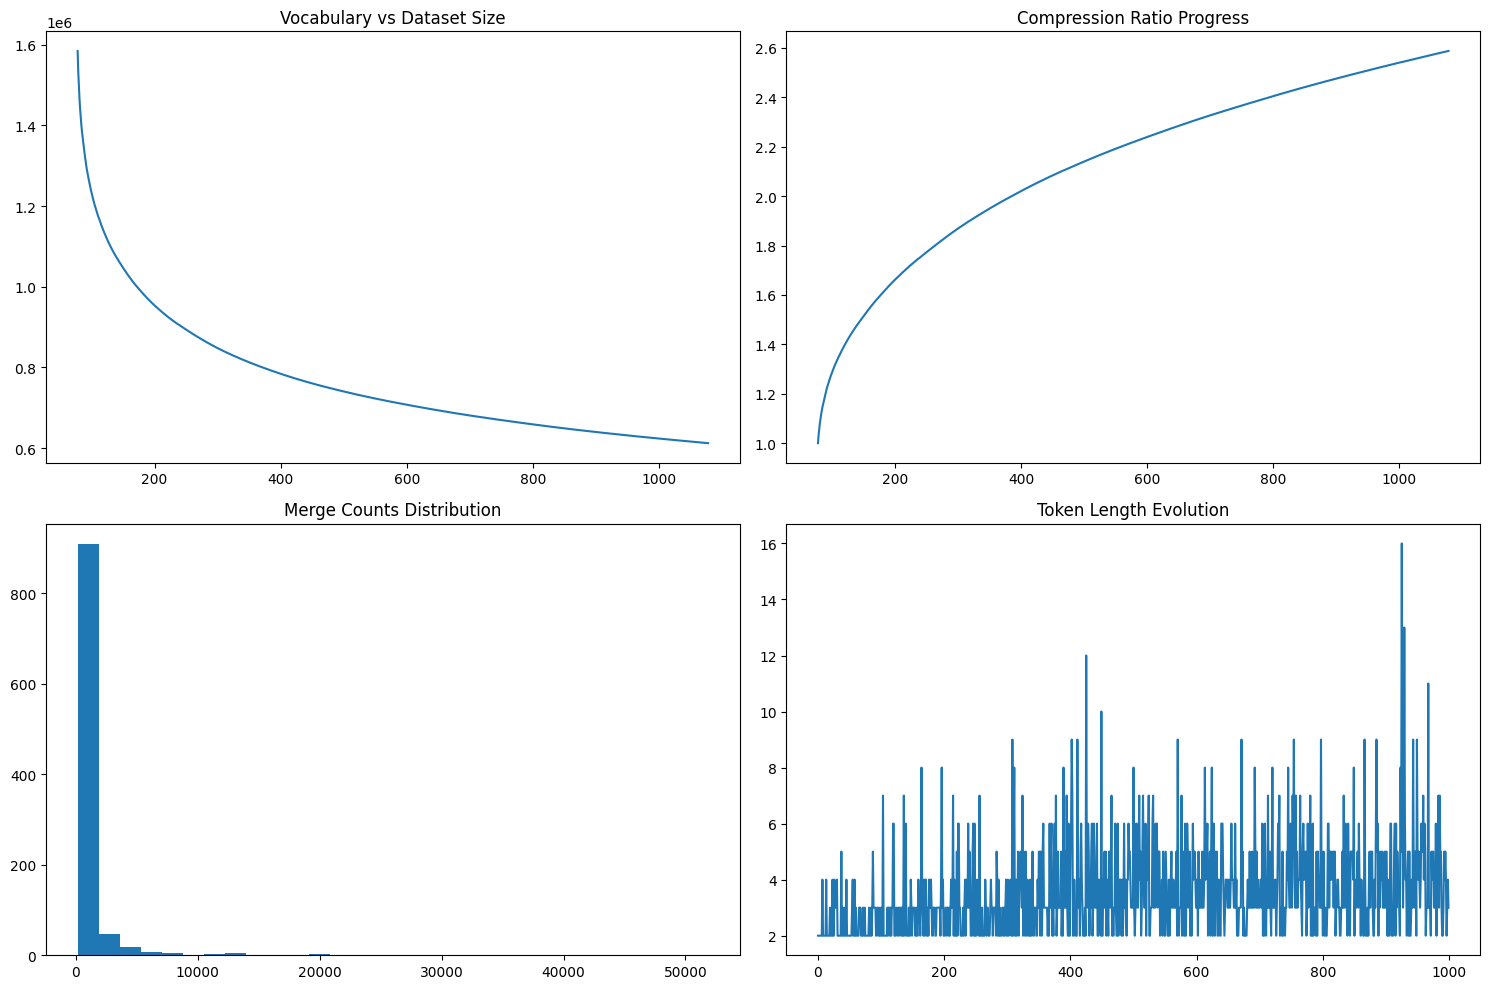

Training BPE:  26%|██▌       | 1178/4500 [19:42<54:43,  1.01it/s]


Iteration 1100:
Vocabulary size: 1,178
Data size: 598,907
Compression ratio: 2.65
Last merge count: 127
Last token created: ' संग'
Max token length: 16


Training BPE:  28%|██▊       | 1278/4500 [21:02<49:01,  1.10it/s]


Iteration 1200:
Vocabulary size: 1,278
Data size: 586,955
Compression ratio: 2.70
Last merge count: 113
Last token created: 'प्रथम '
Max token length: 16


Training BPE:  31%|███       | 1378/4500 [22:22<37:26,  1.39it/s]

...


Iteration 1800:
Vocabulary size: 1,878
Data size: 533,529
Compression ratio: 2.97
Last merge count: 71
Last token created: 'उम्'
Max token length: 19


Training BPE:  44%|████▍     | 1978/4500 [30:09<30:01,  1.40it/s]


Iteration 1900:
Vocabulary size: 1,978
Data size: 526,688
Compression ratio: 3.01
Last merge count: 66
Last token created: 'दौ'
Max token length: 19


Training BPE:  46%|████▌     | 2078/4500 [31:28<39:26,  1.02it/s]


Iteration 2000:
Vocabulary size: 2,078
Data size: 520,265
Compression ratio: 3.05
Last merge count: 62
Last token created: ' मह'
Max token length: 19


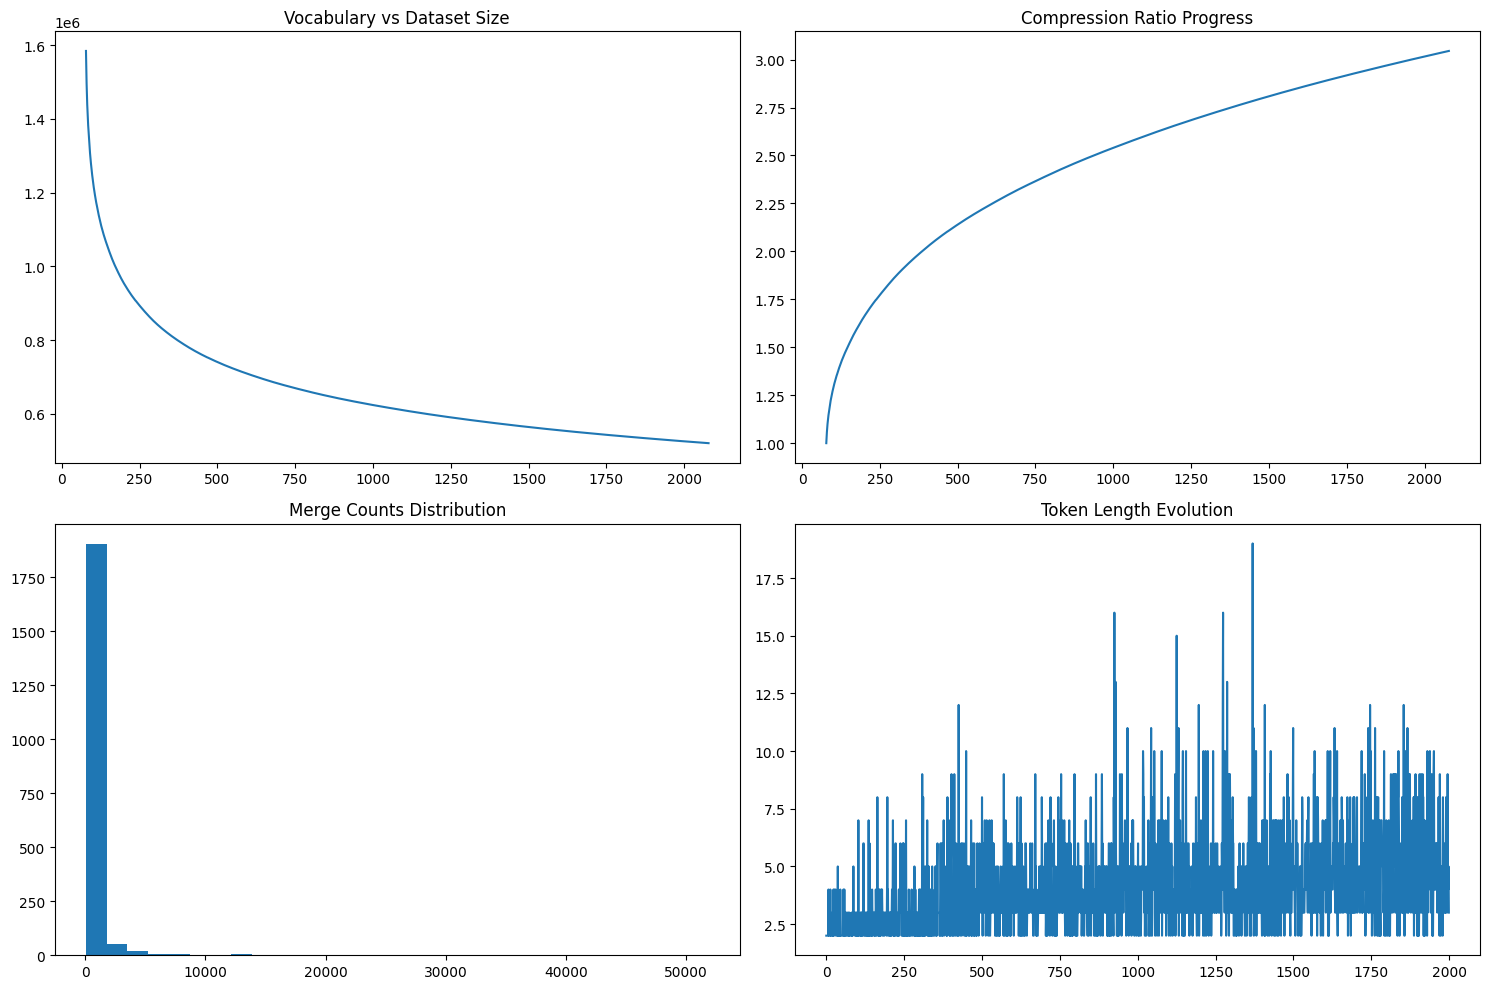

Training BPE:  48%|████▊     | 2178/4500 [32:48<28:03,  1.38it/s]


Iteration 2100:
Vocabulary size: 2,178
Data size: 514,227
Compression ratio: 3.08
Last merge count: 58
Last token created: 'ने पर '
Max token length: 19


Training BPE:  51%|█████     | 2278/4500 [34:07<30:15,  1.22it/s]


Iteration 2200:
Vocabulary size: 2,278
Data size: 508,568
Compression ratio: 3.12
Last merge count: 55
Last token created: '्राष्ट्र'
Max token length: 32


Training BPE:  53%|█████▎    | 2378/4500 [35:19<22:14,  1.59it/s]

...


Iteration 2800:
Vocabulary size: 2,878
Data size: 480,105
Compression ratio: 3.30
Last merge count: 41
Last token created: 'लिप'
Max token length: 164


Training BPE:  66%|██████▌   | 2978/4500 [42:35<21:34,  1.18it/s]


Iteration 2900:
Vocabulary size: 2,978
Data size: 476,109
Compression ratio: 3.33
Last merge count: 39
Last token created: 'टेड'
Max token length: 164


Training BPE:  68%|██████▊   | 3078/4500 [43:47<17:47,  1.33it/s]


Iteration 3000:
Vocabulary size: 3,078
Data size: 472,263
Compression ratio: 3.35
Last merge count: 38
Last token created: 'मूल्य'
Max token length: 164


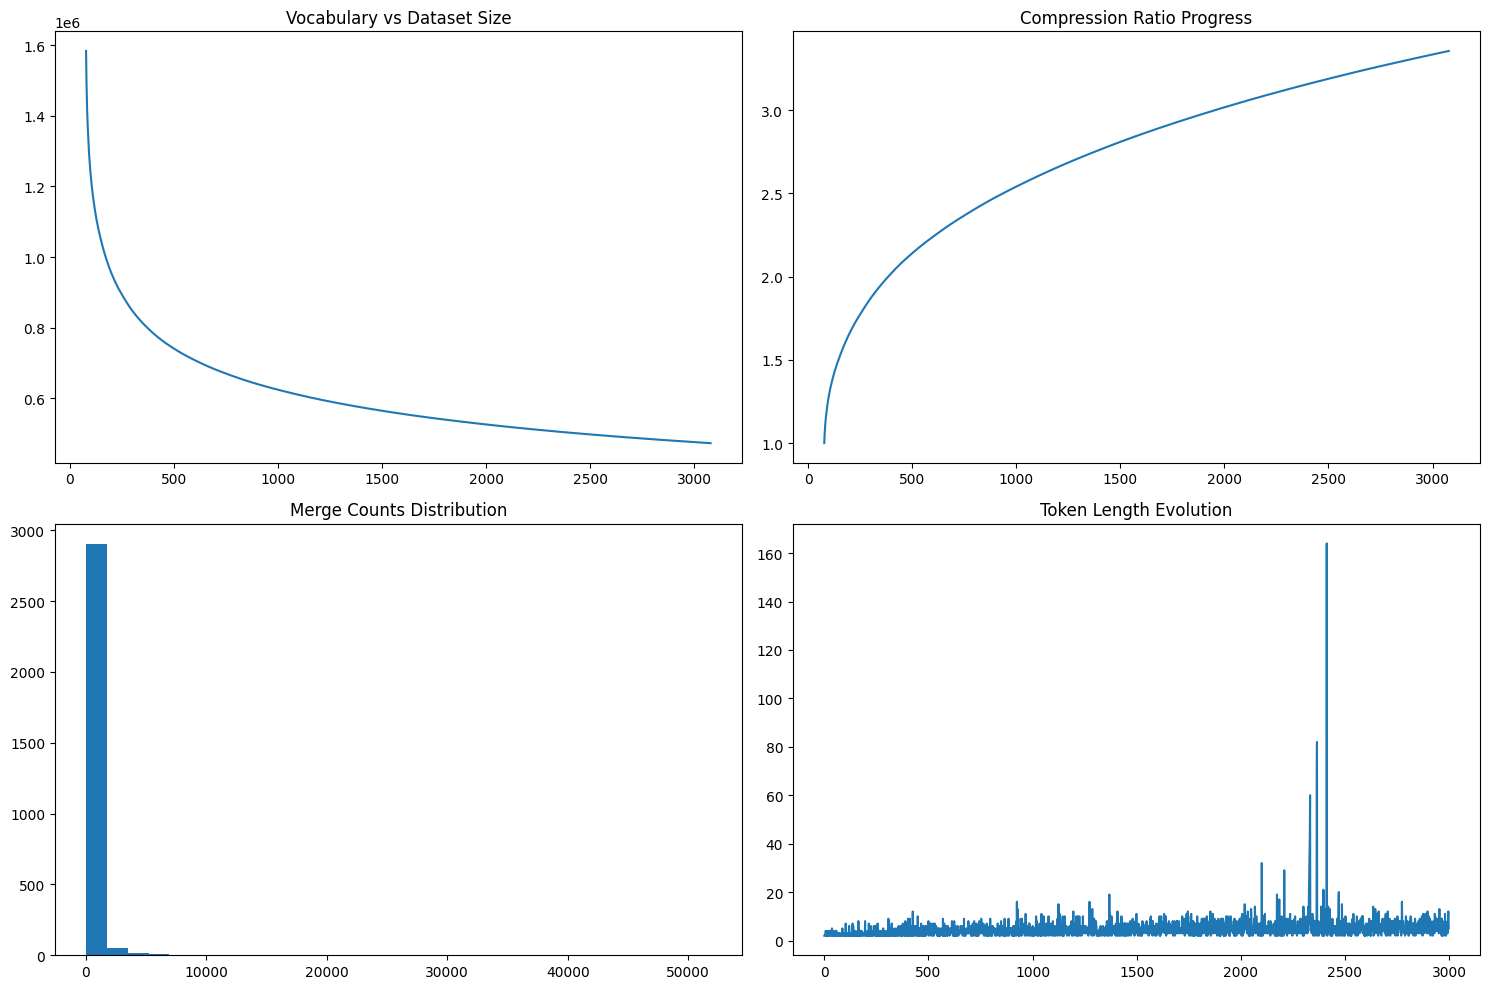

Training BPE:  71%|███████   | 3178/4500 [44:57<15:24,  1.43it/s]


Iteration 3100:
Vocabulary size: 3,178
Data size: 468,594
Compression ratio: 3.38
Last merge count: 36
Last token created: 'री में '
Max token length: 164


Training BPE:  73%|███████▎  | 3278/4500 [46:08<12:45,  1.60it/s]


Iteration 3200:
Vocabulary size: 3,278
Data size: 465,049
Compression ratio: 3.41
Last merge count: 35
Last token created: 'उठा'
Max token length: 164


Training BPE:  75%|███████▌  | 3378/4500 [47:18<11:37,  1.61it/s]

...


Iteration 3800:
Vocabulary size: 3,878
Data size: 446,279
Compression ratio: 3.55
Last merge count: 28
Last token created: ' किंग'
Max token length: 164


Training BPE:  88%|████████▊ | 3978/4500 [54:23<05:49,  1.49it/s]


Iteration 3900:
Vocabulary size: 3,978
Data size: 443,479
Compression ratio: 3.57
Last merge count: 28
Last token created: 'माई'
Max token length: 164


Training BPE:  91%|█████████ | 4078/4500 [55:31<04:12,  1.67it/s]


Iteration 4000:
Vocabulary size: 4,078
Data size: 440,774
Compression ratio: 3.59
Last merge count: 27
Last token created: 'ंगर '
Max token length: 164


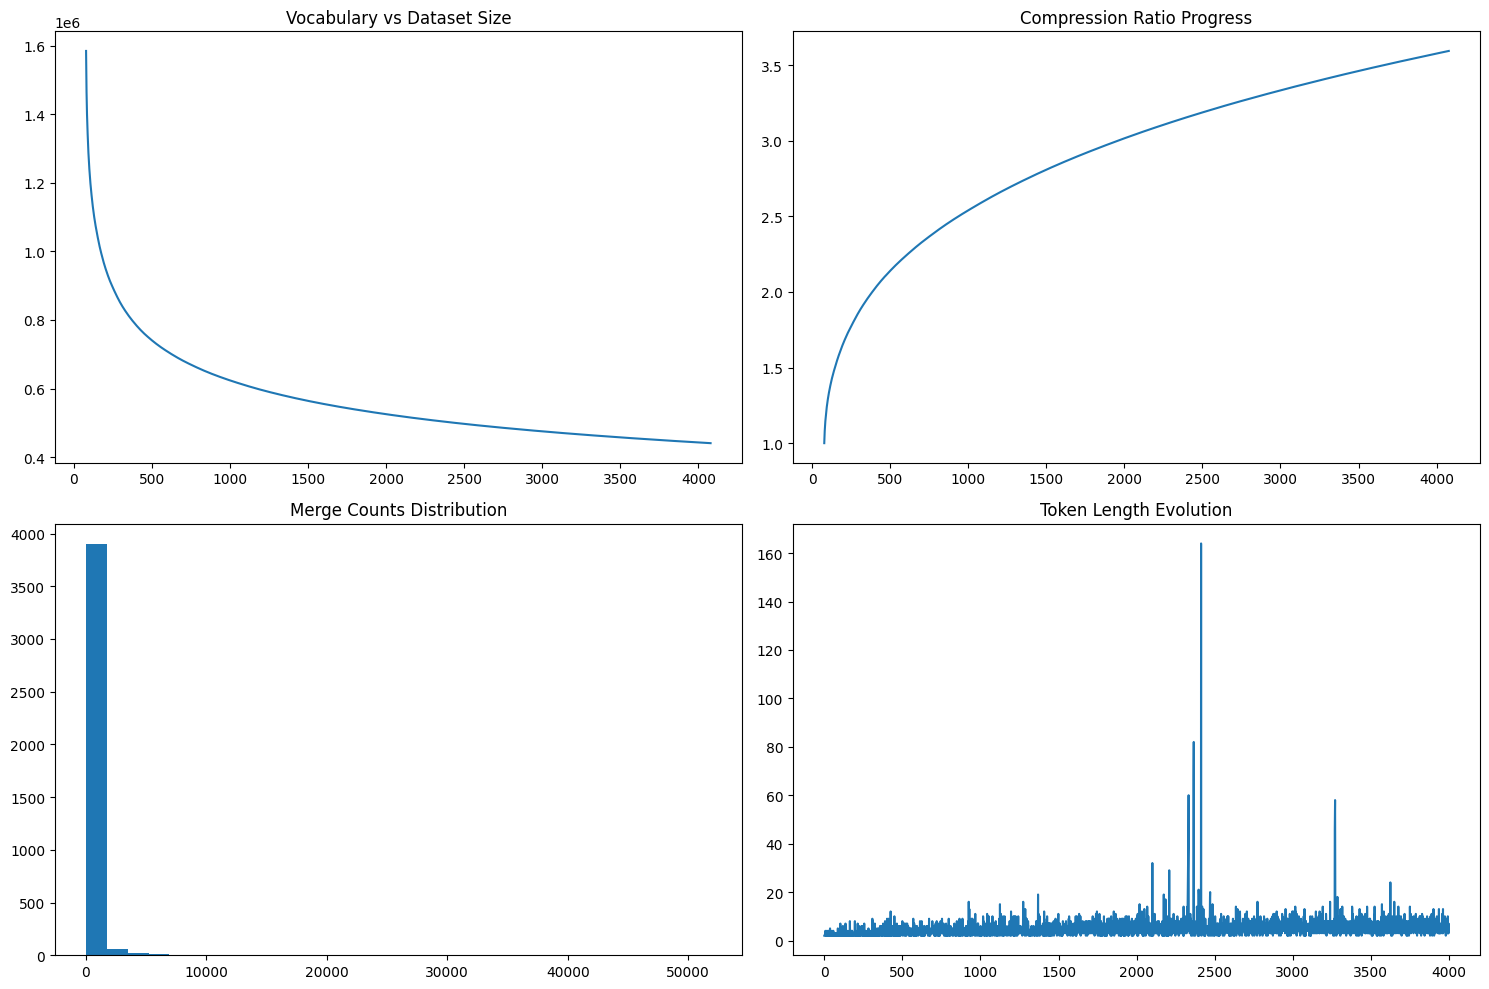

Training BPE:  93%|█████████▎| 4178/4500 [56:41<03:09,  1.70it/s]


Iteration 4100:
Vocabulary size: 4,178
Data size: 438,159
Compression ratio: 3.62
Last merge count: 26
Last token created: 'वहाँ'
Max token length: 164


Training BPE:  95%|█████████▌| 4278/4500 [57:52<02:12,  1.67it/s]


Iteration 4200:
Vocabulary size: 4,278
Data size: 435,605
Compression ratio: 3.64
Last merge count: 25
Last token created: 'भारत के आ'
Max token length: 164


Training BPE:  97%|█████████▋| 4378/4500 [59:00<01:13,  1.67it/s]


Iteration 4300:
Vocabulary size: 4,378
Data size: 433,116
Compression ratio: 3.66
Last merge count: 24
Last token created: 'ाने से '
Max token length: 164


Training BPE: 100%|█████████▉| 4478/4500 [1:00:11<00:15,  1.41it/s]


Iteration 4400:
Vocabulary size: 4,478
Data size: 430,716
Compression ratio: 3.68
Last merge count: 24
Last token created: 'गोवि'
Max token length: 164


Training BPE: 100%|██████████| 4500/4500 [1:00:26<00:00,  1.22it/s]


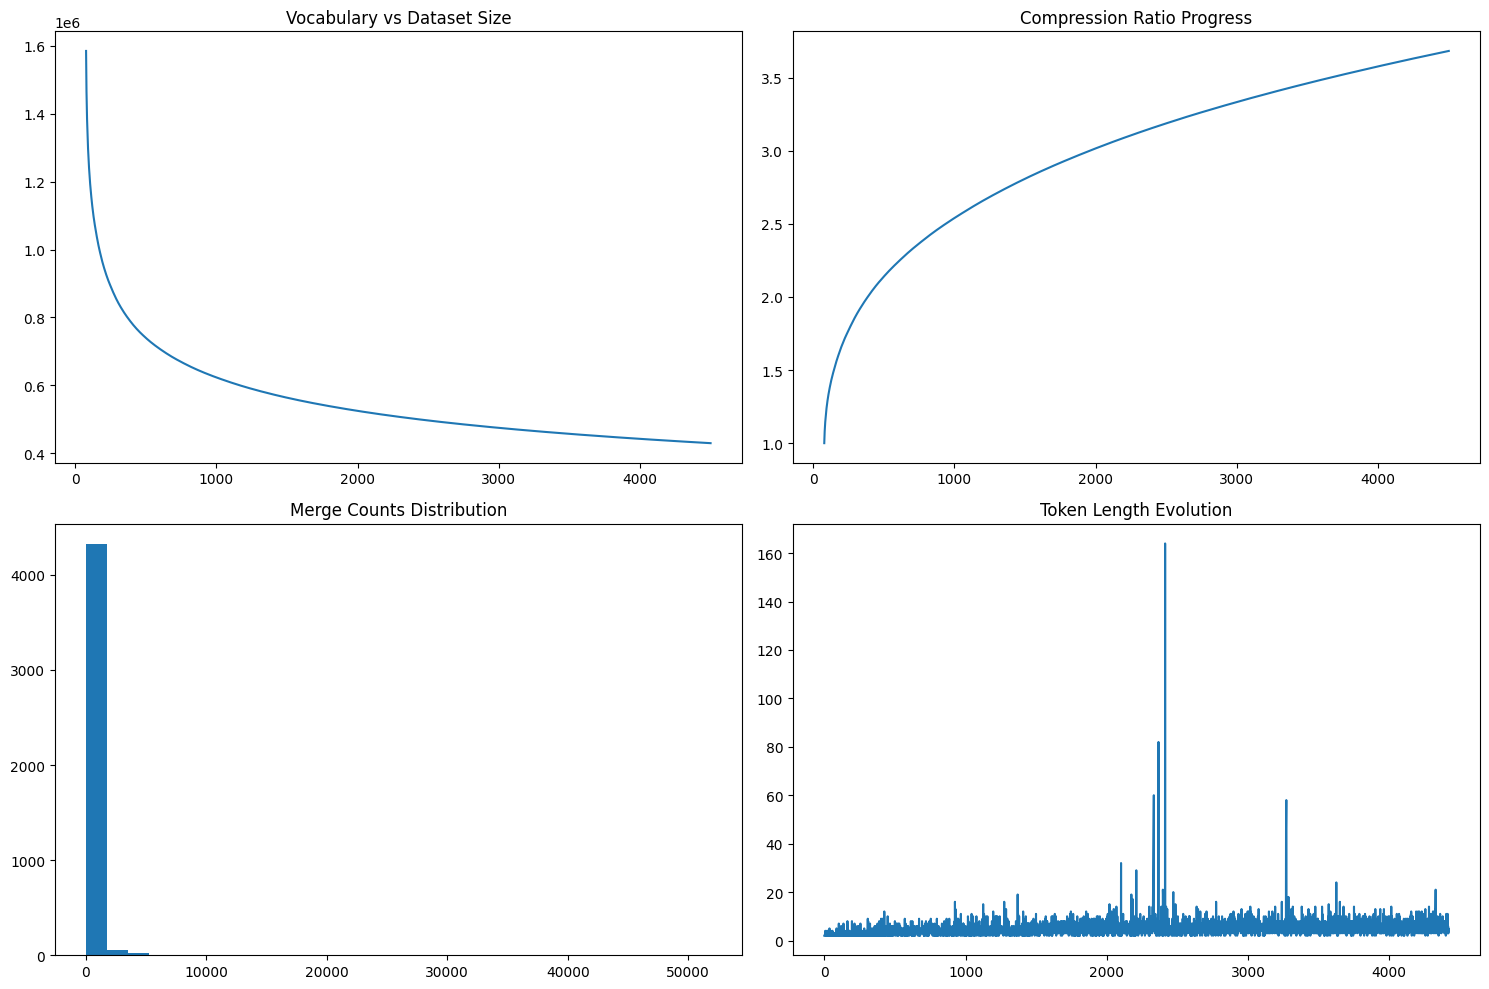

Tokenizer saved to tokenizer


In [27]:
bpe = HindiBPE(vocab_size=vocab_size)
bpe.train(text)

In [45]:
bpe.get_token_statistics()['vocab_size']

4500

In [48]:
bpe.get_token_statistics()['training_stats']['compression_ratios'][-1]

3.6828223939300955

In [30]:
examples=[
            ["हिंदी भाषा बहुत सुंदर है।"],
            ["भारत एक विशाल देश है। यहाँ की संस्कृति बहुत पुरानी है।"],
            ["मैं हिंदी में प्रोग्रामिंग सीख रहा हूं।"]
        ],

In [31]:
def preprocess_hindi_text(text: str) -> str:
    """Preprocess Hindi text for better BPE training."""
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text.strip())

    # Normalize Unicode characters
    text = unicodedata.normalize('NFKC', text)

    # Remove unnecessary punctuation (keep essential ones)
    text = re.sub(r'[^\u0900-\u097F\s।]', '', text)

    return text

In [36]:
examples[0][0][0]

'हिंदी भाषा बहुत सुंदर है।'

In [40]:
input = examples[0][0][0]
text = preprocess_hindi_text(input)
print(f'Input: {text}')
# Tokenize
tokens = bpe.encode(text)
print(tokens)

Input: हिंदी भाषा बहुत सुंदर है।

Tokenizing text...

Encoding completed:
Token count: 6
Unique tokens: 6
Compression ratio: 1.00
['हिंदी ', 'भाषा ', 'बहुत ', 'सु', 'ंदर ', 'है।']


In [41]:
input = examples[0][1][0]
text = preprocess_hindi_text(input)
print(f'Input: {text}')
# Tokenize
tokens = bpe.encode(text)
print(tokens)

Input: भारत एक विशाल देश है। यहाँ की संस्कृति बहुत पुरानी है।

Tokenizing text...

Encoding completed:
Token count: 14
Unique tokens: 14
Compression ratio: 1.00
['भारत ', 'एक ', 'विशाल ', 'देश ', 'है। यह', 'ा', 'ँ ', 'की ', 'संस्कृ', 'ति ', 'बहुत ', 'पुरा', 'नी ', 'है।']


In [42]:
input = examples[0][2][0]
text = preprocess_hindi_text(input)
print(f'Input: {text}')
# Tokenize
tokens = bpe.encode(text)
print(tokens)

Input: मैं हिंदी में प्रोग्रामिंग सीख रहा हूं।

Tokenizing text...

Encoding completed:
Token count: 12
Unique tokens: 12
Compression ratio: 1.00
['मैं ', 'हिंदी ', 'में ', 'प्रोग्रा', 'मि', 'ंग ', 'सी', 'ख ', 'रहा ', 'हू', 'ं', '।']
